<a href="https://colab.research.google.com/github/kong230499-prog/first-repo/blob/main/Delay_coordinate_Noisy_Partial_Measurements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [4]:
"""
Delay-Coordinate State Reconstruction under Noisy Partial Measurements

Split into 13 sections:
1. Imports
2. Output folders / portability setup
3. Nonlinear system definitions
4. Measurement and delay-coordinate functions
5. Baseline functions
6. Metrics
7. Model selection
8. Reconstruction experiment
9. Future-prediction experiment
10. Closed-loop control experiment
11. Plotting functions
12. Diagram functions
13. main()
"""
# 1. Imports
import time
from pathlib import Path
from math import pi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from scipy.integrate import solve_ivp
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Output folders/portability setup

In [5]:
# 2. Output folders / portability setup
PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Nonlinear system definitions

In [6]:
# Nonlinear system definitions

def vanderpol_rhs(t, x, mu=1.0):
    """
    Van der Pol oscillator.

    State:
        x[0] = position
        x[1] = velocity
    """
    x1, x2 = x
    dx1 = x2
    dx2 = mu * (1.0 - x1**2) * x2 - x1
    return [dx1, dx2]

def duffing_rhs(
    t,
    x,
    alpha=-1.0,
    beta=1.0,
    delta=0.2,
    gamma=0.3,
    omega=1.2,
):
    """
    Forced Duffing oscillator.

    State:
        x[0] = displacement
        x[1] = velocity
    """
    x1, x2 = x
    dx1 = x2
    dx2 = (
        -delta * x2
        - alpha * x1
        - beta * x1**3
        + gamma * np.cos(omega * t)
    )
    return [dx1, dx2]

def nonlinear_msd_rhs(
    t,
    x,
    m=1.0,
    c=0.2,
    k=1.0,
    k3=0.5,
):
    """
    Nonlinear mass-spring-damper system.

    Equation:
        m*x_ddot + c*x_dot + k*x + k3*x^3 = 0
    """
    displacement, velocity = x
    acceleration = -(c * velocity + k * displacement + k3 * displacement**3) / m
    return [velocity, acceleration]

def simulate_system(
    system_name="vanderpol",
    dt=0.01,
    t_final=40.0,
    x0=None,
):
    """
    Simulate one nonlinear system and return time and true states.
    """
    if x0 is None:
        x0 = [2.0, 0.0]

    t_eval = np.arange(0.0, t_final + dt, dt)

    if system_name == "vanderpol":
        rhs = lambda t, x: vanderpol_rhs(t, x, mu=1.0)

    elif system_name == "duffing":
        rhs = lambda t, x: duffing_rhs(t, x)

    elif system_name == "nonlinear_msd":
        rhs = lambda t, x: nonlinear_msd_rhs(t, x)

    else:
        raise ValueError(f"Unknown system_name: {system_name}")

    sol = solve_ivp(
        rhs,
        t_span=(0.0, t_final),
        y0=np.asarray(x0, dtype=float),
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11,
    )

    if not sol.success:
        raise RuntimeError(f"ODE integration failed: {sol.message}")

    return sol.t, sol.y.T

# Measurement and delay-coordinate functions

In [7]:
# Measurement and delay-coordinate functions

def make_noisy_measurement(
    states,
    observed_index=0,
    noise_std=0.05,
    seed=0,
):
    """
    Generate a noisy scalar measurement from one state component.

    In this project, the model only observes noisy position.
    """
    rng = np.random.default_rng(seed)
    clean = states[:, observed_index]
    noise = rng.normal(0.0, noise_std, size=clean.shape)
    return clean + noise

def build_delay_embedding(
    measurement,
    states,
    num_delays=20,
    delay_stride=1,
):
    """
    Build delay-coordinate vectors:

        z_k = [y_k, y_{k-s}, y_{k-2s}, ..., y_{k-(q-1)s}]

    where:
        q = num_delays
        s = delay_stride
    """
    measurement = np.asarray(measurement)
    states = np.asarray(states)

    if measurement.ndim != 1:
        raise ValueError("measurement must be a 1D scalar time series.")

    if states.ndim != 2:
        raise ValueError("states must have shape (n_samples, state_dim).")

    if measurement.shape[0] != states.shape[0]:
        raise ValueError("measurement and states must have the same length.")

    if num_delays < 1:
        raise ValueError("num_delays must be at least 1.")

    if delay_stride < 1:
        raise ValueError("delay_stride must be at least 1.")

    max_lag = (num_delays - 1) * delay_stride

    if max_lag >= len(measurement):
        raise ValueError("Delay window is longer than the available signal.")

    features = []
    targets = []
    valid_indices = []

    for k in range(max_lag, len(measurement)):
        delay_vector = [
            measurement[k - j * delay_stride]
            for j in range(num_delays)
        ]

        features.append(delay_vector)
        targets.append(states[k])
        valid_indices.append(k)

    return np.asarray(features), np.asarray(targets), np.asarray(valid_indices)

def build_future_prediction_embedding(
    measurement,
    states,
    num_delays=20,
    delay_stride=1,
    horizon_steps=10,
):
    """
    Build delay-coordinate inputs for future-state prediction.

    Input:
        z_k = [y_k, y_{k-s}, y_{k-2s}, ..., y_{k-(d-1)s}]

    Target:
        x_{k+horizon_steps}

    This converts the problem from reconstruction:
        z_k -> x_k

    into future prediction:
        z_k -> x_{k+h}
    """
    measurement = np.asarray(measurement)
    states = np.asarray(states)

    max_delay = (num_delays - 1) * delay_stride

    X = []
    Y_future = []
    valid_indices = []

    last_valid_index = len(measurement) - horizon_steps

    for k in range(max_delay, last_valid_index):
        delay_vector = []

        for j in range(num_delays):
            delay_index = k - j * delay_stride
            delay_vector.append(measurement[delay_index])

        X.append(delay_vector)
        Y_future.append(states[k + horizon_steps])
        valid_indices.append(k)

    X = np.asarray(X)
    Y_future = np.asarray(Y_future)
    valid_indices = np.asarray(valid_indices)

    return X, Y_future, valid_indices

def chronological_split(
    X,
    Y,
    train_frac=0.70,
    val_frac=0.15,
):
    """
    Chronological train/validation/test split.

    No random shuffling is used because this is time-series data.
    """
    n = len(X)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    X_train = X[:n_train]
    Y_train = Y[:n_train]

    X_val = X[n_train:n_train + n_val]
    Y_val = Y[n_train:n_train + n_val]

    X_test = X[n_train + n_val:]
    Y_test = Y[n_train + n_val:]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

# Baseline functions

In [8]:
# Baseline functions

def baseline_measurement_only(X, dt=0.01, delay_stride=1):
    """
    Measurement-only baseline.

    Delay vector structure:
        X[:, 0] = y_k
        X[:, 1] = y_{k-s}
        X[:, 2] = y_{k-2s}
        ...

    Returns:
        Y_pred with columns [estimated_position, estimated_velocity]
    """
    position_hat = X[:, 0]
    velocity_hat = np.zeros_like(position_hat)

    return np.column_stack([position_hat, velocity_hat])

def baseline_finite_difference(X, dt=0.01, delay_stride=1):
    """
    Finite-difference baseline.

    Uses current noisy position as position estimate and estimates velocity
    using backward finite difference:

        v_hat = (y_k - y_{k-s}) / (delay_stride * dt)

    Requires at least two delayed measurements.
    """
    if X.shape[1] < 2:
        raise ValueError("Finite-difference baseline requires at least two delay coordinates.")

    position_hat = X[:, 0]
    velocity_hat = (X[:, 0] - X[:, 1]) / (delay_stride * dt)

    return np.column_stack([position_hat, velocity_hat])


# Metrics

In [9]:
# Metrics

def rmse(y_true, y_pred):
    """
    Total RMSE over all states.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def per_state_rmse(y_true, y_pred):
    """
    RMSE for each state component.
    """
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))

def nrmse(y_true, y_pred):
    """
    Normalized RMSE using standard deviation of the true states.
    """
    scale = np.std(y_true)
    if scale == 0:
        return np.nan
    return float(rmse(y_true, y_pred) / scale)

def summarize_metrics(y_true, y_pred):
    """
    Return metrics useful for final report tables.
    """
    state_rmse = per_state_rmse(y_true, y_pred)

    return {
        "rmse_total": rmse(y_true, y_pred),
        "nrmse_total": nrmse(y_true, y_pred),
        "rmse_position": float(state_rmse[0]),
        "rmse_velocity": float(state_rmse[1]),
    }


# Model selection

In [10]:
# Model selection

def make_model(model_name="ridge", seed=0):
    """
    Create reconstruction model.
    """
    if model_name == "ridge":
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("regressor", Ridge(alpha=1.0)),
            ]
        )

    elif model_name == "mlp":
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "regressor",
                    MLPRegressor(
                        hidden_layer_sizes=(64, 64),
                        activation="tanh",
                        solver="adam",
                        alpha=1e-4,
                        learning_rate_init=1e-3,
                        max_iter=2000,
                        random_state=seed,
                    ),
                ),
            ]
        )

    else:
        raise ValueError(f"Unknown trainable model_name: {model_name}")

    return model

# Reconstruction experiment

In [11]:
# Reconstruction experiment

def run_experiment(
    system_name="vanderpol",
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=0,
    dt=0.01,
    t_final=40.0,
):
    """
    Full delay-coordinate reconstruction experiment.

    Returns:
        metrics, test_time, Y_test, Y_pred, measurement, t, states
    """
    start_time = time.time()

    t, states = simulate_system(
        system_name=system_name,
        dt=dt,
        t_final=t_final,
        x0=[2.0, 0.0],
    )

    measurement = make_noisy_measurement(
        states,
        observed_index=0,
        noise_std=noise_std,
        seed=seed,
    )

    X, Y, valid_indices = build_delay_embedding(
        measurement,
        states,
        num_delays=num_delays,
        delay_stride=delay_stride,
    )

    aligned_time = t[valid_indices]
    X_train, Y_train, X_val, Y_val, X_test, Y_test = chronological_split(X, Y)

    n_train = len(X_train)
    n_val = len(X_val)
    test_time = aligned_time[n_train + n_val:]

    if model_name in ["baseline", "baseline_measurement"]:
        Y_pred = baseline_measurement_only(
            X_test,
            dt=dt,
            delay_stride=delay_stride,
        )
    elif model_name == "baseline_finite_difference":
        Y_pred = baseline_finite_difference(
            X_test,
            dt=dt,
            delay_stride=delay_stride,
        )
    else:
        model = make_model(model_name=model_name, seed=seed)
        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)

    metrics = summarize_metrics(Y_test, Y_pred)
    metrics.update({
        "system": system_name,
        "model": model_name,
        "num_delays": num_delays,
        "delay_stride": delay_stride,
        "noise_std": noise_std,
        "seed": seed,
        "runtime_sec": time.time() - start_time,
    })

    return metrics, test_time, Y_test, Y_pred, measurement, t, states

def run_seed_average(
    seeds=None,
    system_name="vanderpol",
    model_names=None,
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
):
    if seeds is None:
        seeds = list(range(10))

    if model_names is None:
        model_names = ["baseline", "ridge", "mlp"]

    rows = []

    for model_name in model_names:
        for seed in seeds:
            metrics, *_ = run_experiment(
                system_name=system_name,
                model_name=model_name,
                num_delays=num_delays,
                delay_stride=delay_stride,
                noise_std=noise_std,
                seed=seed,
            )
            rows.append(metrics)

    raw_df = pd.DataFrame(rows)
    raw_df.to_csv(TABLE_DIR / "seed_average_raw_results.csv", index=False)

    summary_df = (
        raw_df
        .groupby("model")[["rmse_total", "rmse_position", "rmse_velocity", "nrmse_total"]]
        .agg(["mean", "std"])
    )

    summary_df.to_csv(TABLE_DIR / "seed_average_summary_results.csv")

    return raw_df, summary_df

def run_delay_sweep(
    delay_values=None,
    system_name="vanderpol",
    model_name="ridge",
    delay_stride=1,
    noise_std=0.05,
    seed=7,
):
    if delay_values is None:
        delay_values = [1, 2, 5, 10, 20, 30, 40, 60, 80, 100]

    results = []

    for q in delay_values:
        metrics, *_ = run_experiment(
            system_name=system_name,
            model_name=model_name,
            num_delays=q,
            delay_stride=delay_stride,
            noise_std=noise_std,
            seed=seed,
        )
        results.append(metrics)

    df = pd.DataFrame(results)
    df.to_csv(TABLE_DIR / "delay_sweep_results.csv", index=False)
    return df

def run_delay_heatmap_sweep(
    delay_values=None,
    stride_values=None,
    system_name="vanderpol",
    model_name="ridge",
    noise_std=0.05,
    seed=7,
):
    if delay_values is None:
        delay_values = [2, 5, 10, 20, 30, 40, 60, 80]

    if stride_values is None:
        stride_values = [1, 2, 5, 10]

    rows = []

    for q in delay_values:
        for stride in stride_values:
            metrics, *_ = run_experiment(
                system_name=system_name,
                model_name=model_name,
                num_delays=q,
                delay_stride=stride,
                noise_std=noise_std,
                seed=seed,
            )
            rows.append(metrics)

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "delay_stride_heatmap_results.csv", index=False)
    return df

def run_noise_sweep(
    noise_values=None,
    system_name="vanderpol",
    model_names=None,
    num_delays=20,
    delay_stride=1,
    seed=7,
):
    if noise_values is None:
        noise_values = [0.00, 0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

    if model_names is None:
        model_names = ["baseline", "ridge", "mlp"]

    results = []

    for model_name in model_names:
        for noise_std in noise_values:
            metrics, *_ = run_experiment(
                system_name=system_name,
                model_name=model_name,
                num_delays=num_delays,
                delay_stride=delay_stride,
                noise_std=noise_std,
                seed=seed,
            )
            results.append(metrics)

    df = pd.DataFrame(results)
    df.to_csv(TABLE_DIR / "noise_sweep_results.csv", index=False)
    return df

def run_model_comparison(
    system_name="vanderpol",
    model_names=None,
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
):
    if model_names is None:
        model_names = ["baseline", "ridge", "mlp"]

    results = []

    for model_name in model_names:
        metrics, *_ = run_experiment(
            system_name=system_name,
            model_name=model_name,
            num_delays=num_delays,
            delay_stride=delay_stride,
            noise_std=noise_std,
            seed=seed,
        )
        results.append(metrics)

    df = pd.DataFrame(results)
    df.to_csv(TABLE_DIR / "model_comparison_results.csv", index=False)
    return df

def add_relative_improvement(model_df, baseline_model="baseline_measurement"):
    """
    Compute percentage improvement in velocity RMSE relative to a selected baseline.
    """
    if baseline_model not in model_df["model"].values:
        baseline_model = model_df["model"].iloc[0]

    baseline_rmse = model_df.loc[
        model_df["model"] == baseline_model,
        "rmse_velocity"
    ].iloc[0]

    model_df = model_df.copy()
    model_df["velocity_rmse_improvement_percent"] = (
        (baseline_rmse - model_df["rmse_velocity"]) / baseline_rmse * 100.0
    )
    model_df["baseline_for_improvement"] = baseline_model

    return model_df

def run_system_comparison(
    systems=None,
    model_names=None,
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
):
    if systems is None:
        systems = ["vanderpol", "duffing", "nonlinear_msd"]

    if model_names is None:
        model_names = ["baseline", "ridge", "mlp"]

    results = []

    for system_name in systems:
        for model_name in model_names:
            metrics, *_ = run_experiment(
                system_name=system_name,
                model_name=model_name,
                num_delays=num_delays,
                delay_stride=delay_stride,
                noise_std=noise_std,
                seed=seed,
            )
            results.append(metrics)

    df = pd.DataFrame(results)
    df.to_csv(TABLE_DIR / "system_comparison_results.csv", index=False)
    return df

# Future-prediction experiment

In [12]:
# Future-prediction experiment

def run_future_prediction_experiment(
    system_name="vanderpol",
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    horizon_steps=10,
    noise_std=0.05,
    seed=0,
    dt=0.01,
    t_final=40.0,
):
    """
    Run open-loop future-state prediction.

    This predicts future state x_{k+h} from current delay-coordinate vector z_k.
    """
    t, states = simulate_system(
        system_name=system_name,
        dt=dt,
        t_final=t_final,
    )

    measurement = make_noisy_measurement(
        states,
        observed_index=0,
        noise_std=noise_std,
        seed=seed,
    )

    X, Y_future, valid_indices = build_future_prediction_embedding(
        measurement,
        states,
        num_delays=num_delays,
        delay_stride=delay_stride,
        horizon_steps=horizon_steps,
    )

    X_train, Y_train, X_val, Y_val, X_test, Y_test = chronological_split(X, Y_future)

    if model_name == "baseline_measurement":
        Y_pred = baseline_measurement_only(
            X_test,
            dt=dt,
            delay_stride=delay_stride,
        )

    elif model_name == "baseline_finite_difference":
        Y_pred = baseline_finite_difference(
            X_test,
            dt=dt,
            delay_stride=delay_stride,
        )

    else:
        model = make_model(model_name=model_name, seed=seed)
        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)

    metrics = summarize_metrics(Y_test, Y_pred)

    # Build matching time vector for the test targets
    future_target_indices = valid_indices + horizon_steps

    n_total = len(X)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    test_indices = future_target_indices[n_train + n_val:]

    test_time = t[test_indices]

    return metrics, test_time, Y_test, Y_pred, measurement, t, states

def run_prediction_horizon_sweep(
    horizon_values=None,
    system_name="vanderpol",
    model_names=None,
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
    dt=0.01,
    t_final=40.0,
):
    """
    Compare future-prediction accuracy across different prediction horizons.
    """
    if horizon_values is None:
        horizon_values = [1, 5, 10, 20, 50, 100]

    if model_names is None:
        model_names = [
            "baseline_measurement",
            "baseline_finite_difference",
            "ridge",
            "mlp",
        ]

    rows = []

    for model_name in model_names:
        for horizon_steps in horizon_values:
            metrics, *_ = run_future_prediction_experiment(
                system_name=system_name,
                model_name=model_name,
                num_delays=num_delays,
                delay_stride=delay_stride,
                horizon_steps=horizon_steps,
                noise_std=noise_std,
                seed=seed,
                dt=dt,
                t_final=t_final,
            )

            row = {
                "model": model_name,
                "horizon_steps": horizon_steps,
                "horizon_time": horizon_steps * dt,
            }
            row.update(metrics)

            rows.append(row)

    return pd.DataFrame(rows)

# Closed-loop control experiment

In [13]:
# Closed-loop control experiment

def nonlinear_msd_controlled_rhs(
    t,
    x,
    u,
    m=1.0,
    c=0.2,
    k=1.0,
    k3=0.5,
):
    """
    Controlled nonlinear mass-spring-damper system.

    Equation:
        m*x_ddot + c*x_dot + k*x + k3*x^3 = u

    State:
        x[0] = displacement
        x[1] = velocity

    Control:
        u = external force
    """
    displacement, velocity = x
    acceleration = (u - c * velocity - k * displacement - k3 * displacement**3) / m
    return np.array([velocity, acceleration])

def pd_controller(
    x_hat,
    kp=2.0,
    kd=1.0,
    reference=0.0,
    u_max=10.0,
):
    """
    Simple PD feedback controller using estimated state.

    Control law:
        u = -kp*(x_hat_position - reference) - kd*x_hat_velocity

    The controller stabilizes the system toward the reference position.
    """
    position_error = x_hat[0] - reference
    velocity = x_hat[1]

    u = -kp * position_error - kd * velocity

    # Saturate control input to avoid unrealistically large forces
    u = np.clip(u, -u_max, u_max)

    return float(u)

def train_reconstruction_model_for_control(
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
    dt=0.01,
    t_final=40.0,
):
    """
    Train a delay-coordinate reconstruction model using open-loop
    nonlinear mass-spring-damper simulation data.

    This model maps:
        delay vector of noisy position measurements -> full state [position, velocity]
    """
    t, states = simulate_system(
        system_name="nonlinear_msd",
        dt=dt,
        t_final=t_final,
        x0=[2.0, 0.0],
    )

    measurement = make_noisy_measurement(
        states,
        observed_index=0,
        noise_std=noise_std,
        seed=seed,
    )

    X, Y, valid_indices = build_delay_embedding(
        measurement,
        states,
        num_delays=num_delays,
        delay_stride=delay_stride,
    )

    X_train, Y_train, X_val, Y_val, X_test, Y_test = chronological_split(X, Y)

    model = make_model(model_name=model_name, seed=seed)
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    metrics = summarize_metrics(Y_test, Y_pred)

    return model, metrics

def build_delay_vector_from_history(
    measurement_history,
    num_delays=20,
    delay_stride=1,
):
    """
    Build one delay vector from the most recent measurement history.

    Returns:
        z_k = [y_k, y_{k-s}, y_{k-2s}, ..., y_{k-(d-1)s}]
    """
    delay_vector = []

    for j in range(num_delays):
        index = -1 - j * delay_stride
        delay_vector.append(measurement_history[index])

    return np.array(delay_vector).reshape(1, -1)

def simulate_closed_loop_control(
    estimator_model,
    controller_type="reconstructed",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=10,
    dt=0.01,
    t_final=20.0,
    x0=None,
    kp=2.0,
    kd=1.0,
    reference=0.0,
    u_max=10.0,
):
    """
    Simulate closed-loop nonlinear mass-spring-damper control.

    controller_type options:
        "true_state"      : controller uses the true simulated state
        "reconstructed"  : controller uses delay-coordinate reconstructed state
        "measurement"    : controller uses noisy position and assumes velocity = 0

    This allows comparison between ideal feedback, reconstructed-state feedback,
    and a simple partial-measurement baseline.
    """
    if x0 is None:
        x0 = np.array([2.0, 0.0], dtype=float)
    else:
        x0 = np.array(x0, dtype=float)

    rng = np.random.default_rng(seed)

    num_steps = int(t_final / dt) + 1
    time_array = np.linspace(0.0, t_final, num_steps)

    states = np.zeros((num_steps, 2))
    estimated_states = np.zeros((num_steps, 2))
    measurements = np.zeros(num_steps)
    controls = np.zeros(num_steps)

    states[0] = x0

    required_history_length = (num_delays - 1) * delay_stride + 1

    # Initialize measurement history using the initial position
    initial_measurement = states[0, 0] + rng.normal(0.0, noise_std)
    measurement_history = [initial_measurement] * required_history_length

    for k in range(num_steps - 1):
        true_state = states[k]

        # Current noisy position-only measurement
        y_k = true_state[0] + rng.normal(0.0, noise_std)
        measurements[k] = y_k
        measurement_history.append(y_k)

        # Choose what state the controller sees
        if controller_type == "true_state":
            x_for_control = true_state.copy()

        elif controller_type == "reconstructed":
            z_k = build_delay_vector_from_history(
                measurement_history,
                num_delays=num_delays,
                delay_stride=delay_stride,
            )
            x_for_control = estimator_model.predict(z_k).ravel()

        elif controller_type == "measurement":
            # Baseline: position measurement is available, velocity is unknown
            x_for_control = np.array([y_k, 0.0])

        else:
            raise ValueError(
                "controller_type must be 'true_state', 'reconstructed', or 'measurement'"
            )

        estimated_states[k] = x_for_control

        # Compute control force
        u_k = pd_controller(
            x_for_control,
            kp=kp,
            kd=kd,
            reference=reference,
            u_max=u_max,
        )
        controls[k] = u_k

        # Integrate one time step using solve_ivp
        sol = solve_ivp(
            lambda t, x: nonlinear_msd_controlled_rhs(t, x, u_k),
            t_span=(time_array[k], time_array[k + 1]),
            y0=true_state,
            t_eval=[time_array[k + 1]],
            rtol=1e-8,
            atol=1e-10,
        )

        if not sol.success:
            raise RuntimeError(f"Closed-loop integration failed: {sol.message}")

        states[k + 1] = sol.y[:, -1]

    # Fill final measurement and estimated state
    measurements[-1] = states[-1, 0] + rng.normal(0.0, noise_std)

    if controller_type == "true_state":
        estimated_states[-1] = states[-1]
    elif controller_type == "measurement":
        estimated_states[-1] = np.array([measurements[-1], 0.0])
    else:
        measurement_history.append(measurements[-1])
        z_final = build_delay_vector_from_history(
            measurement_history,
            num_delays=num_delays,
            delay_stride=delay_stride,
        )
        estimated_states[-1] = estimator_model.predict(z_final).ravel()

    controls[-1] = controls[-2]

    return time_array, states, estimated_states, measurements, controls

def summarize_control_performance(time_array, states, controls, reference=0.0):
    """
    Compute closed-loop control performance metrics.
    """
    position_error = states[:, 0] - reference
    velocity = states[:, 1]

    position_rmse = np.sqrt(np.mean(position_error**2))
    velocity_rmse = np.sqrt(np.mean(velocity**2))
    control_energy = (
        np.trapezoid(controls**2, time_array)
        if hasattr(np, "trapezoid")
        else np.trapz(controls**2, time_array)
    )
    final_position_error = abs(position_error[-1])
    final_velocity_error = abs(velocity[-1])

    return {
        "position_rmse": float(position_rmse),
        "velocity_rmse": float(velocity_rmse),
        "control_energy": float(control_energy),
        "final_position_error": float(final_position_error),
        "final_velocity_error": float(final_velocity_error),
    }

def run_closed_loop_control_comparison(
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
    dt=0.01,
    train_t_final=40.0,
    control_t_final=20.0,
    kp=2.0,
    kd=1.0,
    reference=0.0,
    u_max=10.0,
):
    """
    Train reconstruction model and compare closed-loop control performance.

    Compares:
        1. true-state feedback
        2. reconstructed-state feedback
        3. noisy measurement-only feedback
    """
    estimator_model, reconstruction_metrics = train_reconstruction_model_for_control(
        model_name=model_name,
        num_delays=num_delays,
        delay_stride=delay_stride,
        noise_std=noise_std,
        seed=seed,
        dt=dt,
        t_final=train_t_final,
    )

    controller_types = ["true_state", "reconstructed", "measurement"]

    results = []
    trajectories = {}

    for controller_type in controller_types:
        time_array, states, estimated_states, measurements, controls = simulate_closed_loop_control(
            estimator_model=estimator_model,
            controller_type=controller_type,
            num_delays=num_delays,
            delay_stride=delay_stride,
            noise_std=noise_std,
            seed=seed + 100,
            dt=dt,
            t_final=control_t_final,
            x0=np.array([2.0, 0.0]),
            kp=kp,
            kd=kd,
            reference=reference,
            u_max=u_max,
        )

        control_metrics = summarize_control_performance(
            time_array,
            states,
            controls,
            reference=reference,
        )

        control_metrics["controller_type"] = controller_type
        control_metrics["model_name"] = model_name
        control_metrics["num_delays"] = num_delays
        control_metrics["delay_stride"] = delay_stride
        control_metrics["noise_std"] = noise_std

        results.append(control_metrics)

        trajectories[controller_type] = {
            "time": time_array,
            "states": states,
            "estimated_states": estimated_states,
            "measurements": measurements,
            "controls": controls,
        }

    results_df = pd.DataFrame(results)

    return results_df, trajectories, reconstruction_metrics

# Plotting functions

In [14]:
# Plotting functions

def save_and_show(fig, filename):
    """
    Save figure and display it.

    Works in Colab, Jupyter, and local Python environments.
    """
    path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

def plot_prediction_horizon_sweep():
    """
    Plot prediction error versus prediction horizon.
    """
    df = run_prediction_horizon_sweep()

    fig, ax = plt.subplots(figsize=(8, 5))

    for model_name, group in df.groupby("model"):
        ax.plot(
            group["horizon_time"],
            group["rmse_total"],
            marker="o",
            label=model_name,
        )

    ax.set_title("Open-Loop Future Prediction Error vs Horizon")
    ax.set_xlabel("Prediction horizon [s]")
    ax.set_ylabel("Total RMSE")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_and_show(fig, "open_loop_prediction_horizon_sweep.png")

    table_path = TABLE_DIR / "open_loop_prediction_horizon_sweep.csv"
    df.to_csv(table_path, index=False)
    print(f"Saved: {table_path}")

    return df

def plot_future_prediction_example(
    system_name="vanderpol",
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    horizon_steps=20,
    noise_std=0.05,
    seed=7,
):
    """
    Plot true future state and predicted future state for one horizon.
    """
    metrics, test_time, Y_test, Y_pred, *_ = run_future_prediction_experiment(
        system_name=system_name,
        model_name=model_name,
        num_delays=num_delays,
        delay_stride=delay_stride,
        horizon_steps=horizon_steps,
        noise_std=noise_std,
        seed=seed,
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(test_time, Y_test[:, 0], label="True future position")
    axes[0].plot(test_time, Y_pred[:, 0], "--", label="Predicted future position")
    axes[0].set_ylabel("Position")
    axes[0].set_title(
        f"Open-Loop Future Prediction, horizon = {horizon_steps} steps"
    )
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(test_time, Y_test[:, 1], label="True future velocity")
    axes[1].plot(test_time, Y_pred[:, 1], "--", label="Predicted future velocity")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel("Velocity")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    save_and_show(fig, "open_loop_future_prediction_example.png")

    print(metrics)

    return metrics

def plot_closed_loop_position_comparison(
    trajectories,
    reference=0.0,
    filename="closed_loop_position_comparison.png",
):
    """
    Plot closed-loop position response for different controller types.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    for controller_type, data in trajectories.items():
        time_array = data["time"]
        states = data["states"]

        ax.plot(
            time_array,
            states[:, 0],
            label=controller_type,
        )

    ax.axhline(
        reference,
        linestyle="--",
        color="black",
        linewidth=1.0,
        label="reference",
    )

    ax.set_title("Closed-Loop Position Response")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Position")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_and_show(fig, filename)

def plot_closed_loop_control_input(
    trajectories,
    filename="closed_loop_control_input.png",
):
    """
    Plot control input over time for each controller type.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    for controller_type, data in trajectories.items():
        time_array = data["time"]
        controls = data["controls"]

        ax.plot(
            time_array,
            controls,
            label=controller_type,
        )

    ax.set_title("Closed-Loop Control Input")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Control force u")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_and_show(fig, filename)

def plot_reconstructed_state_in_closed_loop(
    trajectories,
    filename="closed_loop_reconstructed_state.png",
):
    """
    Plot true vs reconstructed state during closed-loop control.
    """
    data = trajectories["reconstructed"]

    time_array = data["time"]
    states = data["states"]
    estimated_states = data["estimated_states"]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(time_array, states[:, 0], label="True position")
    axes[0].plot(time_array, estimated_states[:, 0], "--", label="Estimated position")
    axes[0].set_ylabel("Position")
    axes[0].set_title("Closed-Loop True vs Reconstructed State")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(time_array, states[:, 1], label="True velocity")
    axes[1].plot(time_array, estimated_states[:, 1], "--", label="Estimated velocity")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel("Velocity")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    save_and_show(fig, filename)

def plot_closed_loop_phase_portrait(
    trajectories,
    filename="closed_loop_phase_portrait.png",
):
    """
    Plot phase portrait of closed-loop trajectories.
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    for controller_type, data in trajectories.items():
        states = data["states"]

        ax.plot(
            states[:, 0],
            states[:, 1],
            label=controller_type,
        )

    ax.set_title("Closed-Loop Phase Portrait")
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_and_show(fig, filename)

def plot_noisy_measurement(system_name="vanderpol", noise_std=0.05, seed=7):
    t, states = simulate_system(system_name=system_name)
    measurement = make_noisy_measurement(states, noise_std=noise_std, seed=seed)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, states[:, 0], label="True position")
    ax.plot(t, measurement, alpha=0.7, label="Noisy measured position")
    ax.set_xlabel("Time")
    ax.set_ylabel("Position")
    ax.set_title("Noisy Scalar Measurement of Position")
    ax.legend()
    ax.grid(True)

    save_and_show(fig, "01_noisy_measurement.png")

def plot_true_vs_reconstructed(
    system_name="vanderpol",
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
):
    metrics, test_time, Y_test, Y_pred, measurement, t, states = run_experiment(
        system_name=system_name,
        model_name=model_name,
        num_delays=num_delays,
        delay_stride=delay_stride,
        noise_std=noise_std,
        seed=seed,
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(test_time, Y_test[:, 0], label="True position")
    axes[0].plot(test_time, Y_pred[:, 0], "--", label="Estimated position")
    axes[0].set_ylabel("Position")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(test_time, Y_test[:, 1], label="True velocity")
    axes[1].plot(test_time, Y_pred[:, 1], "--", label="Estimated velocity")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Velocity")
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle("Delay-Coordinate State Reconstruction from Noisy Position")
    save_and_show(fig, "02_true_vs_reconstructed_states.png")

    return metrics

def plot_error_time_series(
    system_name="vanderpol",
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
):
    metrics, test_time, Y_test, Y_pred, *_ = run_experiment(
        system_name=system_name,
        model_name=model_name,
        num_delays=num_delays,
        delay_stride=delay_stride,
        noise_std=noise_std,
        seed=seed,
    )

    errors = Y_test - Y_pred

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(test_time, errors[:, 0])
    axes[0].set_ylabel("Position Error")
    axes[0].grid(True)

    axes[1].plot(test_time, errors[:, 1])
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Velocity Error")
    axes[1].grid(True)

    fig.suptitle("State Reconstruction Error Over Time")
    save_and_show(fig, "03_error_time_series.png")

def plot_phase_portrait_overlay(
    system_name="vanderpol",
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
):
    metrics, test_time, Y_test, Y_pred, *_ = run_experiment(
        system_name=system_name,
        model_name=model_name,
        num_delays=num_delays,
        delay_stride=delay_stride,
        noise_std=noise_std,
        seed=seed,
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(Y_test[:, 0], Y_test[:, 1], label="True trajectory")
    ax.plot(Y_pred[:, 0], Y_pred[:, 1], "--", label="Estimated trajectory")
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title("True vs Reconstructed Phase Portrait")
    ax.legend()
    ax.grid(True)

    save_and_show(fig, "04_phase_portrait_overlay.png")

def plot_delay_sweep():
    df = run_delay_sweep()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(df["num_delays"], df["rmse_total"], marker="o", label="Total RMSE")
    ax.plot(df["num_delays"], df["rmse_velocity"], marker="s", label="Velocity RMSE")
    ax.set_xlabel("Number of Delays")
    ax.set_ylabel("Test RMSE")
    ax.set_title("Effect of Delay Window Length on Reconstruction Accuracy")
    ax.legend()
    ax.grid(True)

    save_and_show(fig, "05_delay_window_sweep.png")
    return df

def plot_delay_stride_heatmap():
    df = run_delay_heatmap_sweep()

    pivot = df.pivot(
        index="num_delays",
        columns="delay_stride",
        values="rmse_velocity",
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, aspect="auto", origin="lower")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("Delay Stride")
    ax.set_ylabel("Number of Delays")
    ax.set_title("Delay Embedding Hyperparameter Heatmap\nColor = Velocity RMSE")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Velocity RMSE")

    save_and_show(fig, "06_delay_stride_heatmap.png")
    return df

def plot_noise_robustness():
    df = run_noise_sweep()

    fig, ax = plt.subplots(figsize=(7, 4))

    for model_name in df["model"].unique():
        subset = df[df["model"] == model_name]
        ax.plot(
            subset["noise_std"],
            subset["rmse_velocity"],
            marker="o",
            label=model_name,
        )

    ax.set_xlabel("Measurement Noise Standard Deviation")
    ax.set_ylabel("Velocity RMSE")
    ax.set_title("Reconstruction Robustness to Measurement Noise")
    ax.legend()
    ax.grid(True)

    save_and_show(fig, "07_noise_robustness_curve.png")
    return df

def plot_model_comparison_bar():
    df = run_model_comparison()

    x = np.arange(len(df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width / 2, df["rmse_position"], width, label="Position RMSE")
    ax.bar(x + width / 2, df["rmse_velocity"], width, label="Velocity RMSE")

    ax.set_xticks(x)
    ax.set_xticklabels(df["model"])
    ax.set_ylabel("RMSE")
    ax.set_title("Baseline vs Delay-Based Reconstruction Models")
    ax.legend()
    ax.grid(True, axis="y")

    save_and_show(fig, "08_model_comparison_bar.png")
    return df

def plot_system_comparison_bar():
    df = run_system_comparison()

    systems = df["system"].unique()
    models = df["model"].unique()

    x = np.arange(len(systems))
    width = 0.25

    fig, ax = plt.subplots(figsize=(9, 4))

    for i, model_name in enumerate(models):
        subset = df[df["model"] == model_name]
        ax.bar(
            x + (i - 1) * width,
            subset["rmse_velocity"],
            width,
            label=model_name,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(systems)
    ax.set_ylabel("Velocity RMSE")
    ax.set_title("System Comparison: Missing Velocity Reconstruction")
    ax.legend()
    ax.grid(True, axis="y")

    save_and_show(fig, "09_system_comparison_bar.png")
    return df

def plot_predicted_vs_true_scatter(
    system_name="vanderpol",
    model_name="ridge",
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
    seed=7,
):
    metrics, test_time, Y_test, Y_pred, *_ = run_experiment(
        system_name=system_name,
        model_name=model_name,
        num_delays=num_delays,
        delay_stride=delay_stride,
        noise_std=noise_std,
        seed=seed,
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    state_names = ["Position", "Velocity"]

    for i, ax in enumerate(axes):
        ax.scatter(Y_test[:, i], Y_pred[:, i], s=8, alpha=0.6)

        min_val = min(Y_test[:, i].min(), Y_pred[:, i].min())
        max_val = max(Y_test[:, i].max(), Y_pred[:, i].max())

        ax.plot([min_val, max_val], [min_val, max_val], "k--")
        ax.set_xlabel(f"True {state_names[i]}")
        ax.set_ylabel(f"Predicted {state_names[i]}")
        ax.set_title(f"Predicted vs True {state_names[i]}")
        ax.grid(True)

    fig.suptitle("Predicted vs True State Values")
    save_and_show(fig, "10_predicted_vs_true_scatter.png")

def plot_seed_average_bar(
    seeds=None,
    system_name="vanderpol",
    model_names=None,
    num_delays=20,
    delay_stride=1,
    noise_std=0.05,
):
    """
    Plot mean velocity RMSE with standard deviation error bars across seeds.
    """
    raw_df, summary_df = run_seed_average(
        seeds=seeds,
        system_name=system_name,
        model_names=model_names,
        num_delays=num_delays,
        delay_stride=delay_stride,
        noise_std=noise_std,
    )

    grouped = (
        raw_df
        .groupby("model")["rmse_velocity"]
        .agg(["mean", "std"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        grouped["model"],
        grouped["mean"],
        yerr=grouped["std"],
        capsize=6,
    )

    ax.set_xlabel("Model")
    ax.set_ylabel("Velocity RMSE")
    ax.set_title("Seed-Averaged Missing Velocity Reconstruction")
    ax.grid(True, axis="y")

    save_and_show(fig, "11_seed_average_velocity_rmse.png")

    return raw_df, summary_df

# Diagram functions

In [15]:
# Diagram functions

def draw_box(ax, xy, text, width=3.2, height=0.7):
    rect = Rectangle(xy, width, height, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10,
    )
    return rect

def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5,
    )
    ax.add_patch(arrow)

def diagram_project_pipeline():
    fig, ax = plt.subplots(figsize=(7, 8))
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 9)
    ax.axis("off")

    boxes = [
        ((1.9, 7.8), "Nonlinear System\nSimulation"),
        ((1.9, 6.5), "True State\nx(t) = [position, velocity]"),
        ((1.9, 5.2), "Partial Measurement\ny(t) = position + noise"),
        ((1.9, 3.9), "Delay Vector\nz_k = [y_k, y_{k-s}, ...]"),
        ((1.9, 2.6), "Regression / Neural Network\nEstimator"),
        ((1.9, 1.3), "Estimated State\nx_hat(t)"),
        ((1.9, 0.0), "Evaluation\nRMSE, Phase Portrait, Sweeps"),
    ]

    for xy, text in boxes:
        draw_box(ax, xy, text)

    for y in [7.8, 6.5, 5.2, 3.9, 2.6, 1.3]:
        draw_arrow(ax, (3.5, y), (3.5, y - 0.55))

    ax.set_title("Delay-Coordinate Reconstruction Pipeline", fontsize=13)

    save_and_show(fig, "diagram_01_project_pipeline.png")

def diagram_delay_coordinate_construction():
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)
    ax.axis("off")

    # Measurement time series boxes
    y_positions = [0.8, 2.0, 3.2, 4.4, 5.6]
    labels = ["y_{k-4s}", "y_{k-3s}", "y_{k-2s}", "y_{k-s}", "y_k"]

    for x_pos, label in zip(y_positions, labels):
        draw_box(ax, (x_pos, 3.2), label, width=1.0, height=0.6)

    ax.text(3.2, 4.3, "Noisy scalar measurement history", ha="center", fontsize=11)

    # Delay vector box
    draw_box(
        ax,
        (6.8, 2.6),
        "Delay Vector z_k\n[y_k, y_{k-s}, ..., y_{k-4s}]",
        width=2.5,
        height=1.1,
    )

    # Output state estimate
    draw_box(
        ax,
        (6.8, 0.7),
        "Estimated State\n[x_hat_position, x_hat_velocity]",
        width=2.5,
        height=1.1,
    )

    draw_arrow(ax, (5.9, 3.5), (6.8, 3.2))
    draw_arrow(ax, (8.05, 2.6), (8.05, 1.8))

    ax.set_title("Delay Coordinate Construction", fontsize=13)

    save_and_show(fig, "diagram_02_delay_coordinate_construction.png")

def diagram_stretch_controller():
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")

    draw_box(ax, (0.5, 3.0), "Reference /\nDesired Behavior", width=2.0, height=0.8)
    draw_box(ax, (3.0, 3.0), "Controller", width=1.8, height=0.8)
    draw_box(ax, (5.4, 3.0), "Nonlinear\nSystem", width=1.8, height=0.8)
    draw_box(ax, (7.8, 3.0), "Noisy Scalar\nMeasurement", width=1.8, height=0.8)
    draw_box(ax, (5.4, 1.0), "Delay-Coordinate\nState Estimator", width=2.2, height=0.8)

    draw_arrow(ax, (2.5, 3.4), (3.0, 3.4))
    draw_arrow(ax, (4.8, 3.4), (5.4, 3.4))
    draw_arrow(ax, (7.2, 3.4), (7.8, 3.4))

    # Measurement to estimator
    draw_arrow(ax, (8.7, 3.0), (6.5, 1.8))

    # Estimator feedback to controller
    draw_arrow(ax, (5.4, 1.4), (3.9, 3.0))

    ax.text(
        4.6,
        0.3,
        "Stretch goal: use reconstructed state for feedback or predictive control",
        ha="center",
        fontsize=10,
    )

    ax.set_title("Closed-Loop Control Architecture", fontsize=13)

    save_and_show(fig, "diagram_03_stretch_controller.png")

# Main

Running sanity-check reconstruction experiment...
Sanity-check metrics:
{'rmse_total': 0.16293745450641922, 'nrmse_total': 0.11322497222993112, 'rmse_position': 0.02009440569792198, 'rmse_velocity': 0.22955052389770358, 'system': 'vanderpol', 'model': 'ridge', 'num_delays': 20, 'delay_stride': 1, 'noise_std': 0.05, 'seed': 7, 'runtime_sec': 0.2172408103942871}
t shape: (4001,)
states shape: (4001, 2)
measurement shape: (4001,)
Y_test shape: (598, 2)
Y_pred shape: (598, 2)

Running model comparison...
   rmse_total  nrmse_total  rmse_position  rmse_velocity     system  \
0    1.066220     0.740914       0.050103       1.507030  vanderpol   
1    5.081955     3.531443       0.050103       7.186796  vanderpol   
2    0.162937     0.113225       0.020094       0.229551  vanderpol   
3    0.114121     0.079303       0.032334       0.158120  vanderpol   

                        model  num_delays  delay_stride  noise_std  seed  \
0        baseline_measurement          20             1       

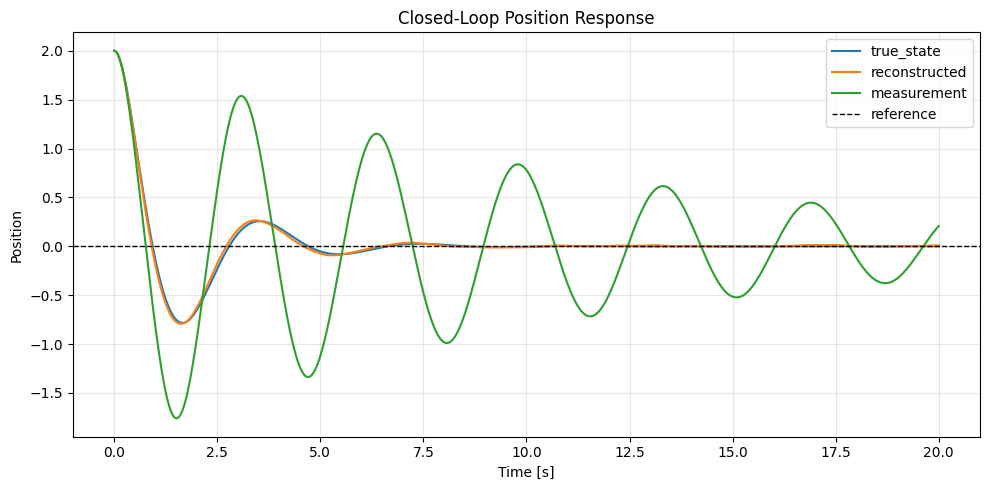

Saved: /content/outputs/figures/closed_loop_position_comparison.png


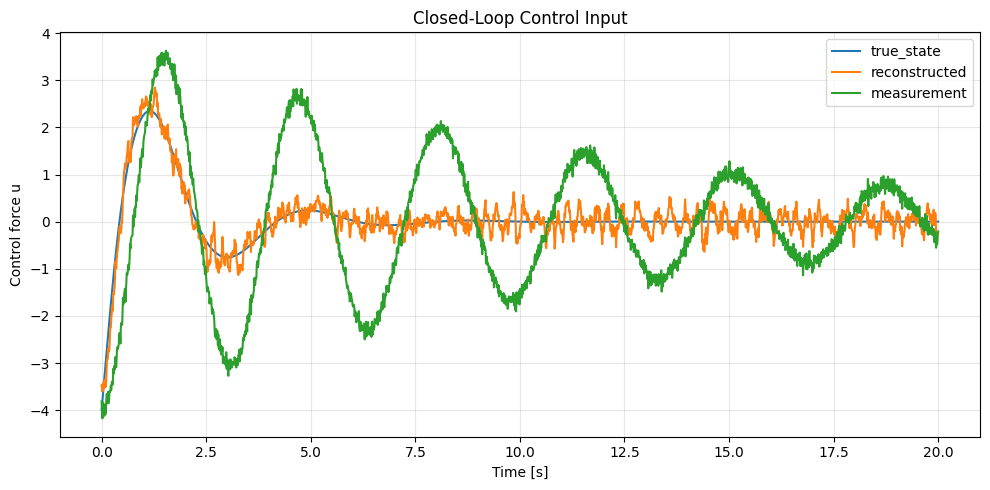

Saved: /content/outputs/figures/closed_loop_control_input.png


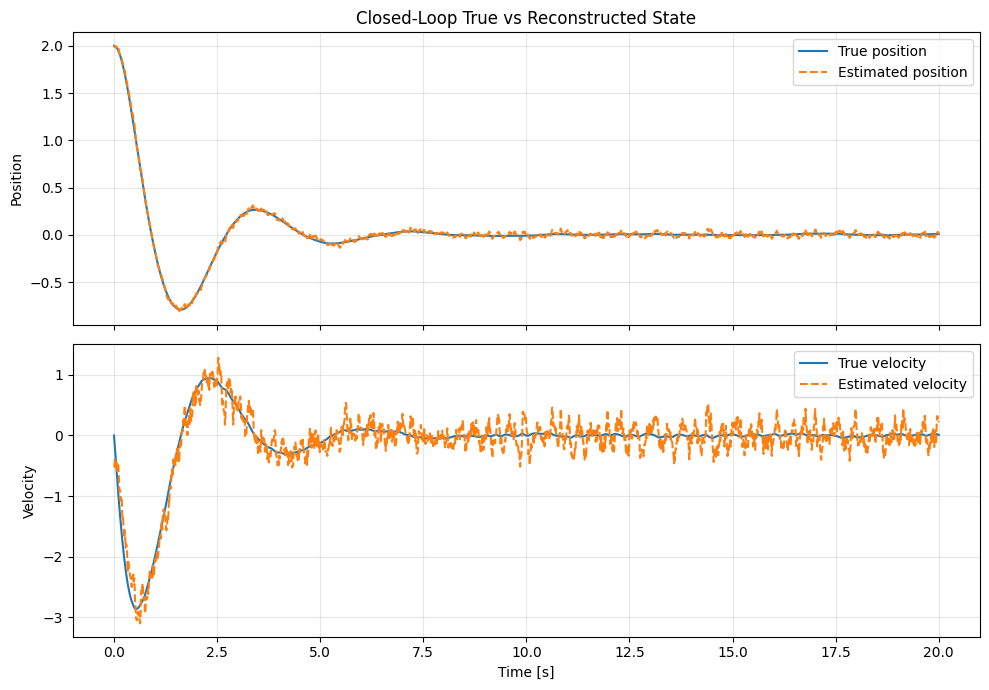

Saved: /content/outputs/figures/closed_loop_reconstructed_state.png


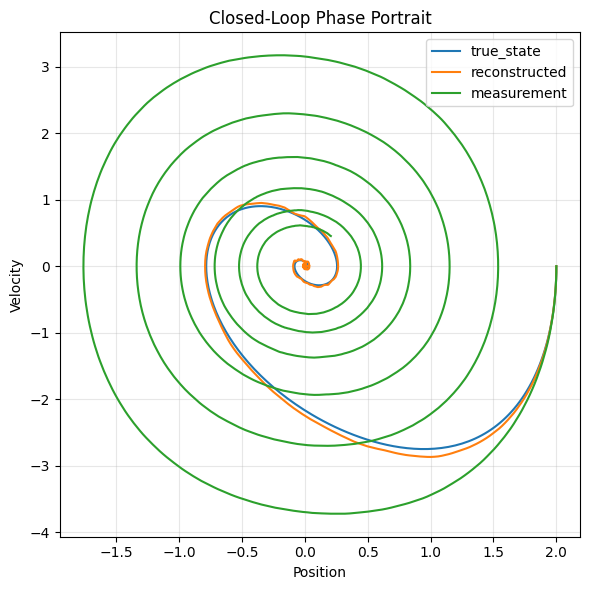

Saved: /content/outputs/figures/closed_loop_phase_portrait.png

Running optional plots and parameter sweeps...


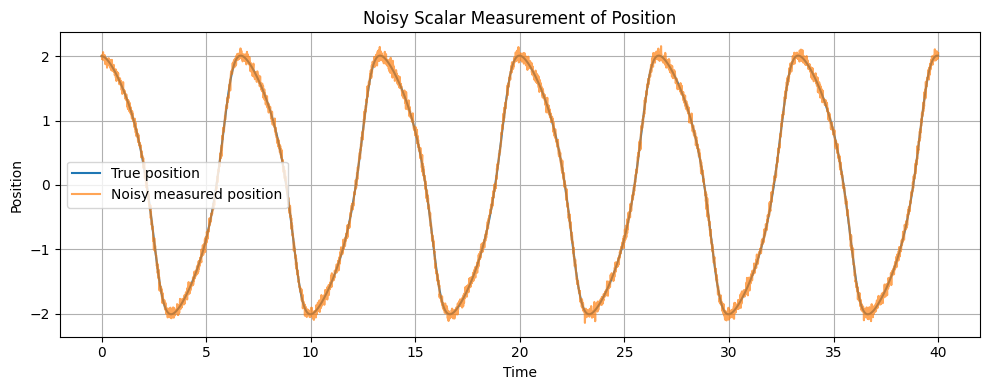

Saved: /content/outputs/figures/01_noisy_measurement.png


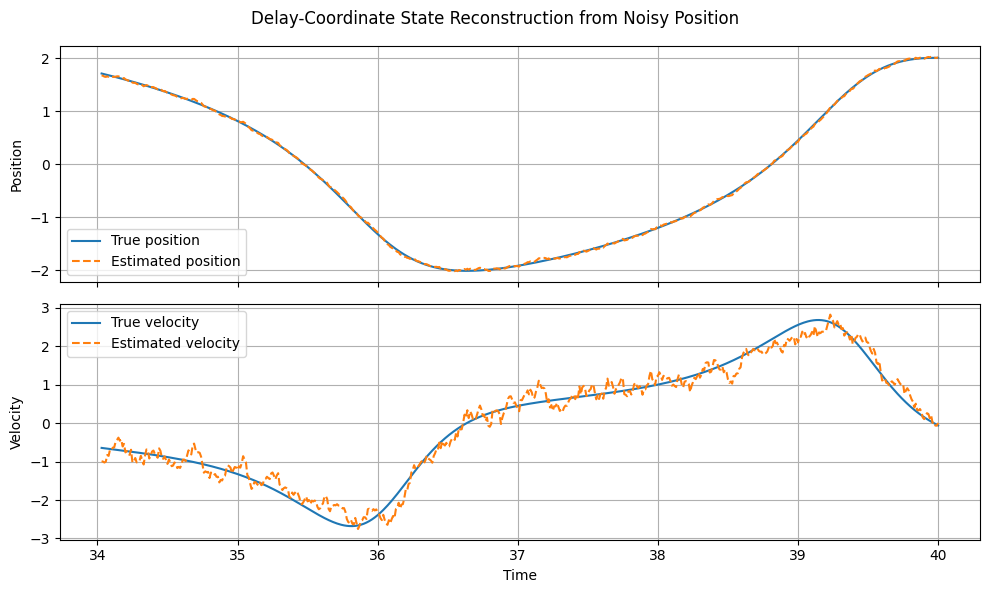

Saved: /content/outputs/figures/02_true_vs_reconstructed_states.png


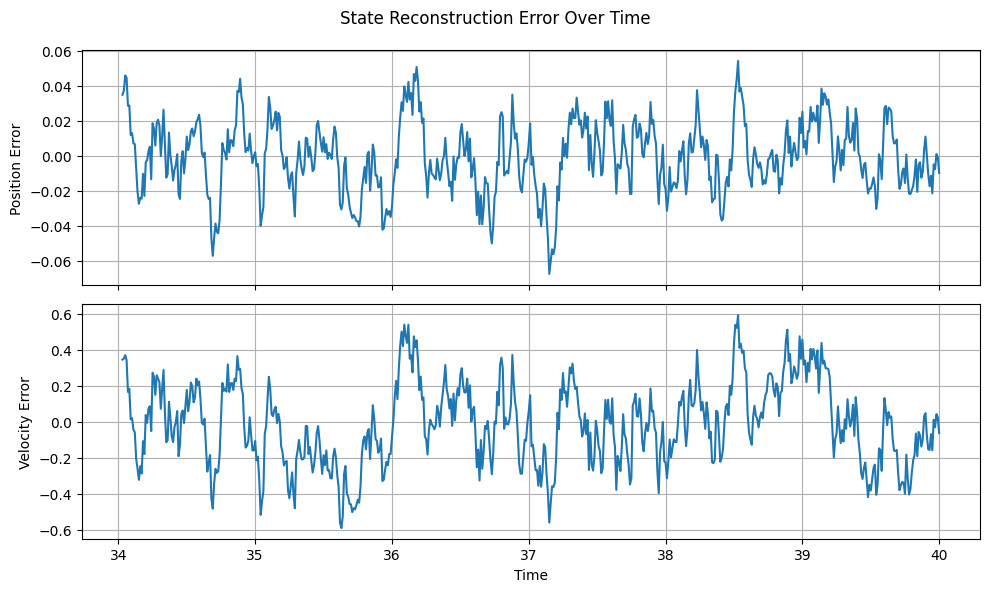

Saved: /content/outputs/figures/03_error_time_series.png


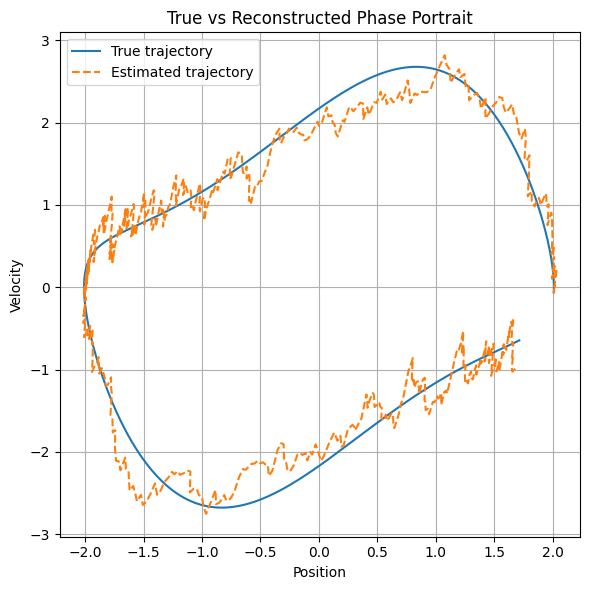

Saved: /content/outputs/figures/04_phase_portrait_overlay.png


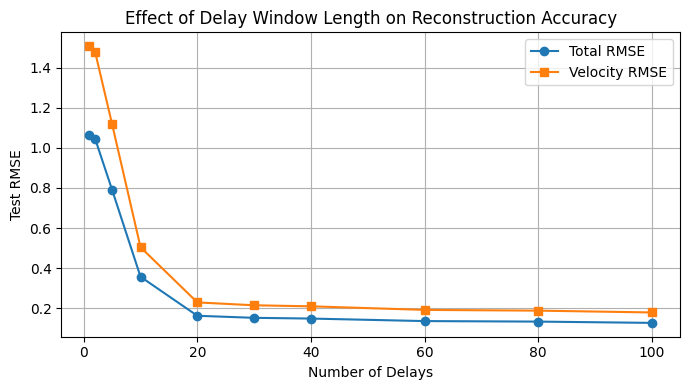

Saved: /content/outputs/figures/05_delay_window_sweep.png


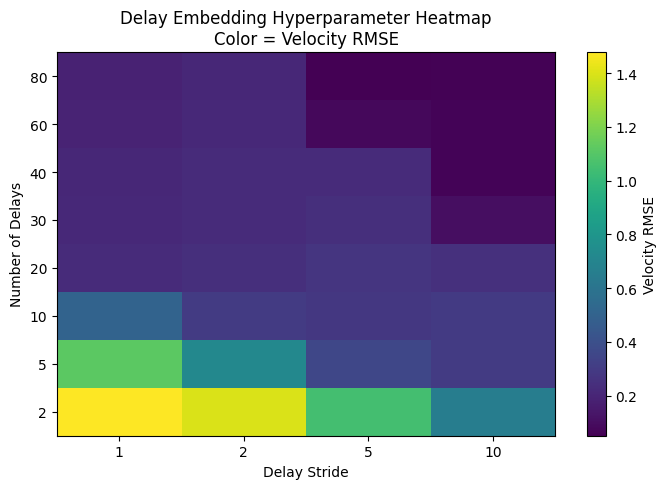

Saved: /content/outputs/figures/06_delay_stride_heatmap.png


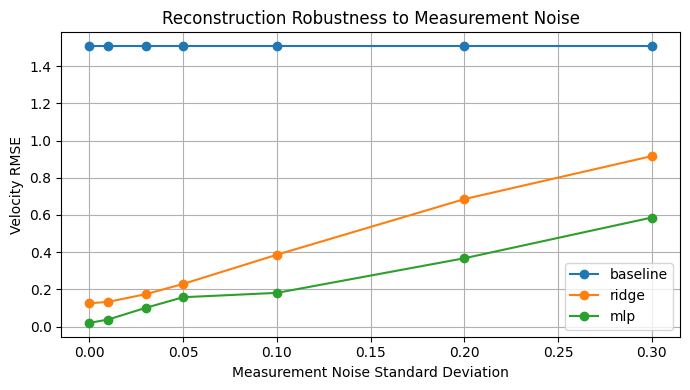

Saved: /content/outputs/figures/07_noise_robustness_curve.png


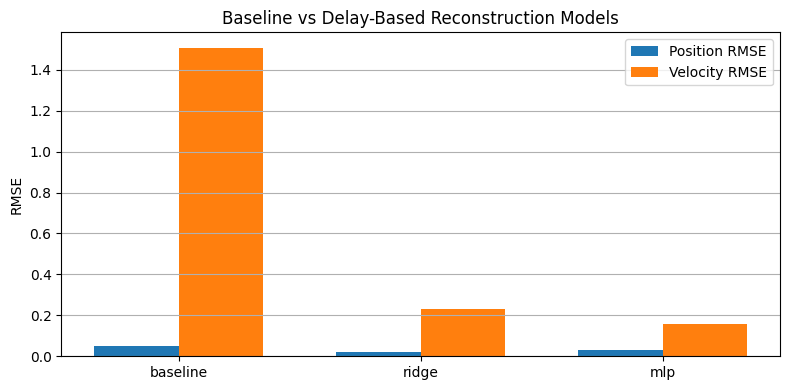

Saved: /content/outputs/figures/08_model_comparison_bar.png


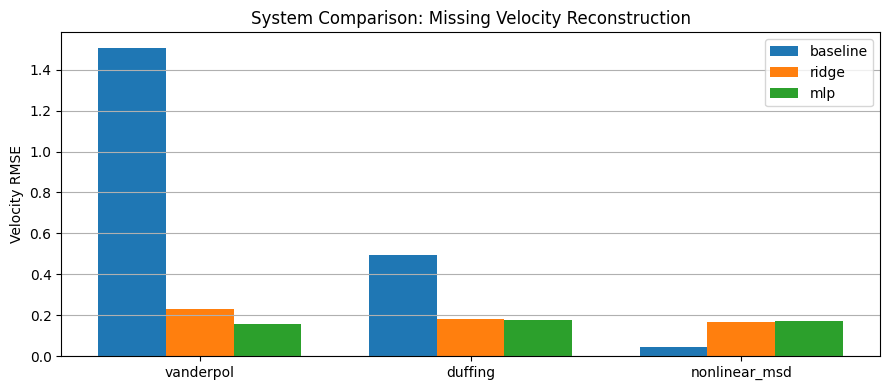

Saved: /content/outputs/figures/09_system_comparison_bar.png


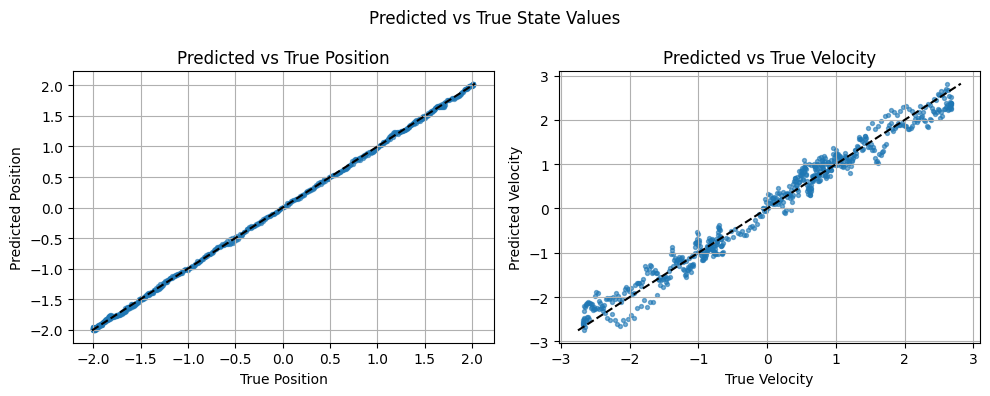

Saved: /content/outputs/figures/10_predicted_vs_true_scatter.png


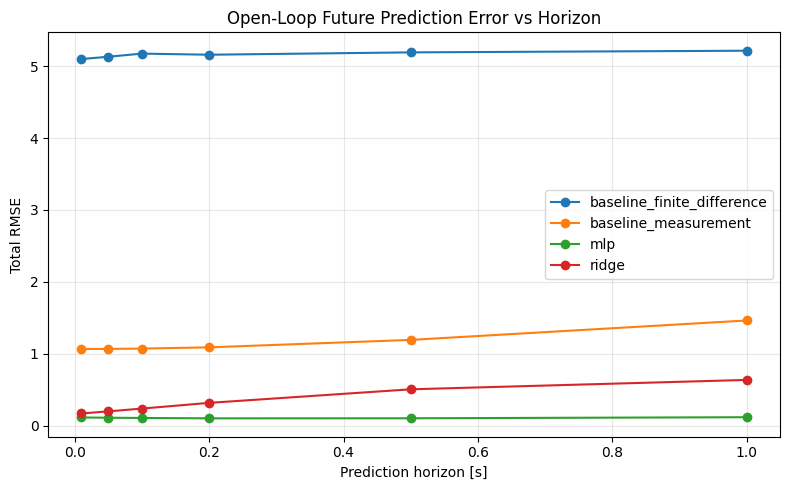

Saved: /content/outputs/figures/open_loop_prediction_horizon_sweep.png
Saved: /content/outputs/tables/open_loop_prediction_horizon_sweep.csv


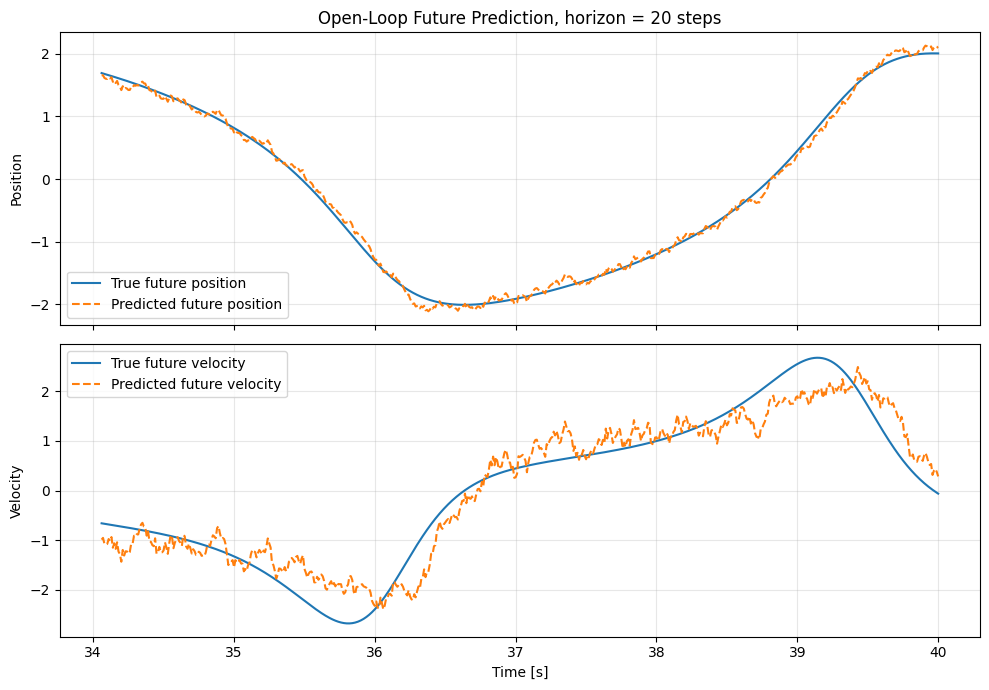

Saved: /content/outputs/figures/open_loop_future_prediction_example.png
{'rmse_total': 0.31699556295957687, 'nrmse_total': 0.220197776220129, 'rmse_position': 0.07980711748135162, 'rmse_velocity': 0.4411385245831924}


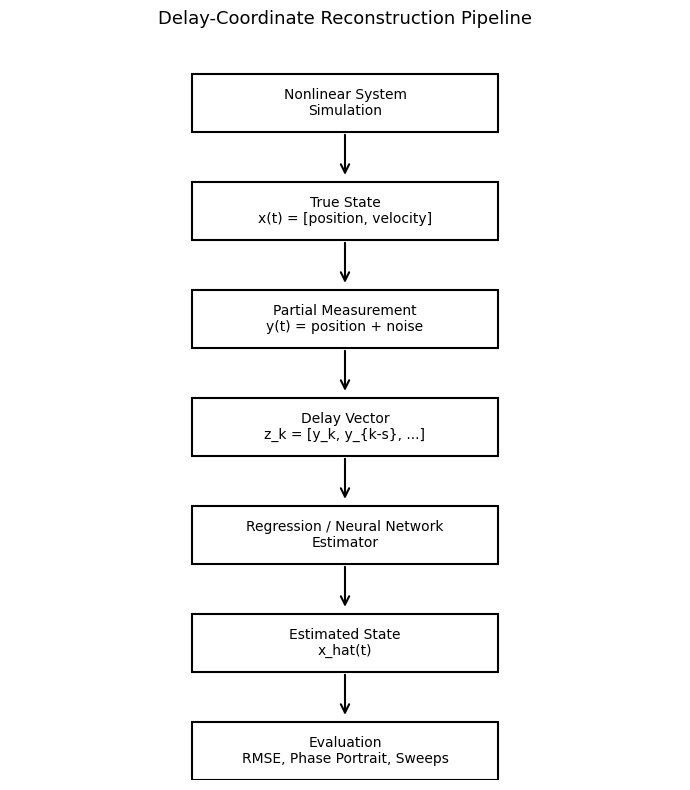

Saved: /content/outputs/figures/diagram_01_project_pipeline.png


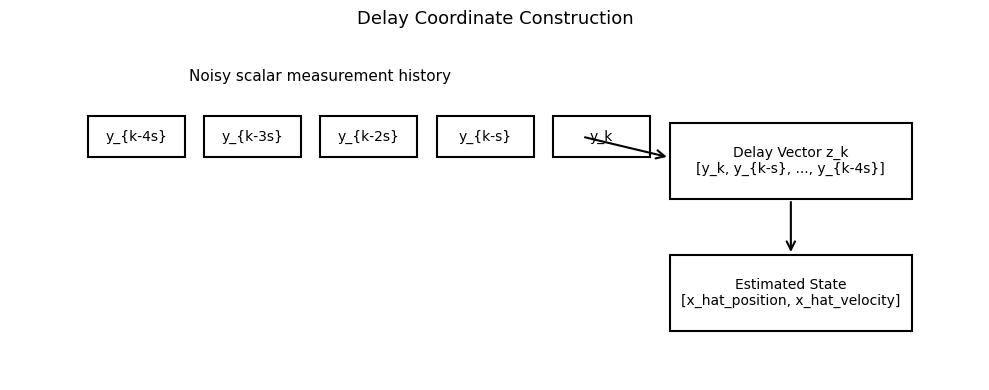

Saved: /content/outputs/figures/diagram_02_delay_coordinate_construction.png


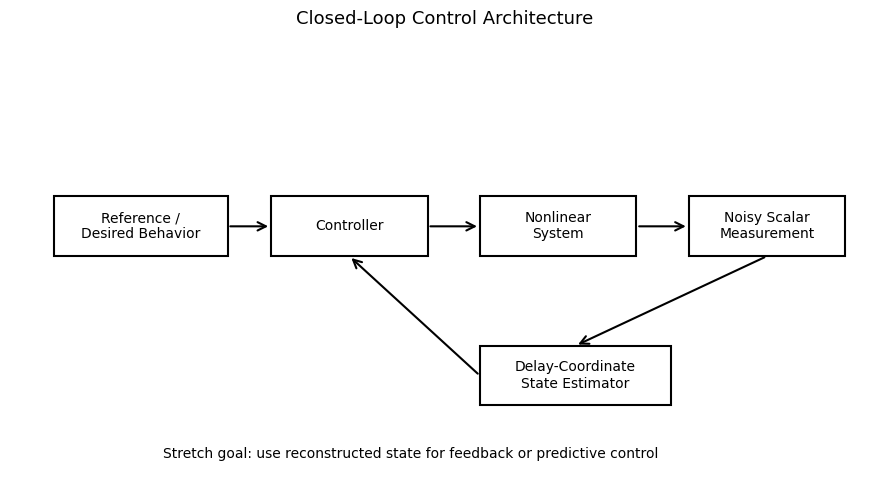

Saved: /content/outputs/figures/diagram_03_stretch_controller.png


In [16]:
# main()
def main(run_all=False):
    """
    Main script execution for the cleaned .py file.

    Parameters
    ----------
    run_all : bool
        If False, run a compact set of representative experiments.
        If True, also run the heavier sweeps/plots that take longer.
    """
    print("Running sanity-check reconstruction experiment...")
    metrics, test_time, Y_test, Y_pred, measurement, t, states = run_experiment(
        system_name="vanderpol",
        model_name="ridge",
        num_delays=20,
        delay_stride=1,
        noise_std=0.05,
        seed=7,
    )
    print("Sanity-check metrics:")
    print(metrics)
    print("t shape:", t.shape)
    print("states shape:", states.shape)
    print("measurement shape:", measurement.shape)
    print("Y_test shape:", Y_test.shape)
    print("Y_pred shape:", Y_pred.shape)

    print("\nRunning model comparison...")
    model_df = run_model_comparison(
        system_name="vanderpol",
        model_names=["baseline_measurement", "baseline_finite_difference", "ridge", "mlp"],
        num_delays=20,
        delay_stride=1,
        noise_std=0.05,
        seed=7,
    )
    model_df = add_relative_improvement(model_df, baseline_model="baseline_measurement")
    print(model_df)
    model_table_path = TABLE_DIR / "model_comparison.csv"
    model_df.to_csv(model_table_path, index=False)
    print(f"Saved: {model_table_path}")

    print("\nRunning future prediction horizon sweep...")
    prediction_horizon_df = run_prediction_horizon_sweep(
        system_name="vanderpol",
        model_names=["baseline_measurement", "baseline_finite_difference", "ridge"],
        num_delays=20,
        delay_stride=1,
        noise_std=0.05,
        seed=7,
    )
    print(prediction_horizon_df)
    prediction_table_path = TABLE_DIR / "prediction_horizon_sweep.csv"
    prediction_horizon_df.to_csv(prediction_table_path, index=False)
    print(f"Saved: {prediction_table_path}")

    print("\nRunning closed-loop control comparison...")
    control_df, control_trajectories, reconstruction_metrics_control = run_closed_loop_control_comparison(
        model_name="ridge",
        num_delays=20,
        delay_stride=1,
        noise_std=0.05,
        seed=7,
        dt=0.01,
        train_t_final=40.0,
        control_t_final=20.0,
        kp=2.0,
        kd=1.0,
        reference=0.0,
        u_max=10.0,
    )
    print("Reconstruction metrics used before control:")
    print(reconstruction_metrics_control)
    print("Closed-loop control performance:")
    print(control_df)
    control_table_path = TABLE_DIR / "closed_loop_control_results.csv"
    control_df.to_csv(control_table_path, index=False)
    print(f"Saved: {control_table_path}")

    plot_closed_loop_position_comparison(control_trajectories)
    plot_closed_loop_control_input(control_trajectories)
    plot_reconstructed_state_in_closed_loop(control_trajectories)
    plot_closed_loop_phase_portrait(control_trajectories)

    if run_all:
        print("\nRunning optional plots and parameter sweeps...")
        plot_noisy_measurement()
        plot_true_vs_reconstructed()
        plot_error_time_series()
        plot_phase_portrait_overlay()
        plot_delay_sweep()
        plot_delay_stride_heatmap()
        plot_noise_robustness()
        plot_model_comparison_bar()
        plot_system_comparison_bar()
        plot_predicted_vs_true_scatter()
        plot_prediction_horizon_sweep()
        plot_future_prediction_example()
        diagram_project_pipeline()
        diagram_delay_coordinate_construction()
        diagram_stretch_controller()


if __name__ == "__main__":
    main(run_all=True)